In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("NumPy:", np.__version__)
print("pandas:", pd.__version__)

NumPy: 2.5.3
pandas: 3.0.5


In [2]:
data_path = "../data/training.csv"
df = pd.read_csv(data_path)
df.shape

(250000, 33)

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
EventId,250000.0,224999.500000,72168.927986,100000.000000,162499.750000,224999.500000,287499.250000,349999.00000
DER_mass_MMC,250000.0,-49.023079,406.345647,-999.000000,78.100750,105.012000,130.606250,1192.02600
DER_mass_transverse_met_lep,250000.0,49.239819,35.344886,0.000000,19.241000,46.524000,73.598000,690.07500
DER_mass_vis,250000.0,81.181982,40.828691,6.329000,59.388750,73.752000,92.259000,1349.35100
DER_pt_h,250000.0,57.895962,63.655682,0.000000,14.068750,38.467500,79.169000,2834.99900
DER_deltaeta_jet_jet,250000.0,-708.420675,454.480565,-999.000000,-999.000000,-999.000000,0.490000,8.50300
DER_mass_jet_jet,250000.0,-601.237051,657.972302,-999.000000,-999.000000,-999.000000,83.446000,4974.97900
DER_prodeta_jet_jet,250000.0,-709.356603,453.019877,-999.000000,-999.000000,-999.000000,-4.593000,16.69000
DER_deltar_tau_lep,250000.0,2.373100,0.782911,0.208000,1.810000,2.491500,2.961000,5.68400
DER_pt_tot,250000.0,18.917332,22.273494,0.000000,2.841000,12.315500,27.591000,2834.99900


In [ ]:
df["Label"].value_counts(normalize=True)

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497,0.000814,s
1,100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,...,1,46.226,0.725,1.158,-999.000,-999.00,-999.000,46.226,0.681042,b
2,100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,...,1,44.251,2.053,-2.028,-999.000,-999.00,-999.000,44.251,0.715742,b
3,100003,143.905,81.417,80.943,0.414,-999.00,-999.000,-999.000,3.310,0.414,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,1.660654,b
4,100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,1.904263,b
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,349995,-999.000,71.989,36.548,5.042,-999.00,-999.000,-999.000,1.392,5.042,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,1.373644,b
249996,349996,-999.000,58.179,68.083,22.439,-999.00,-999.000,-999.000,2.585,22.439,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,0.761439,b
249997,349997,105.457,60.526,75.839,39.757,-999.00,-999.000,-999.000,2.390,22.183,...,1,41.992,1.800,-0.166,-999.000,-999.00,-999.000,41.992,0.005721,s
249998,349998,94.951,19.362,68.812,13.504,-999.00,-999.000,-999.000,3.365,13.504,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,0.512740,b


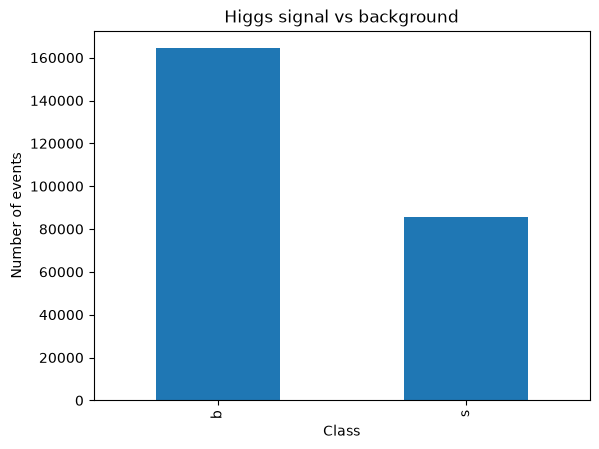

In [9]:
df["Label"].value_counts().plot(kind="bar")

plt.xlabel("Class")
plt.ylabel("Number of events")
plt.title("Higgs signal vs background")
plt.show()

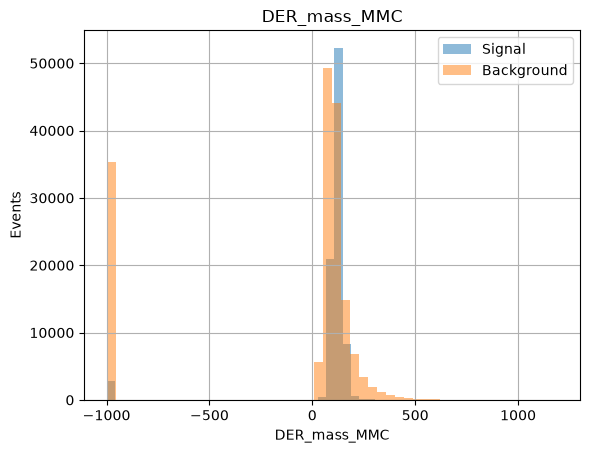

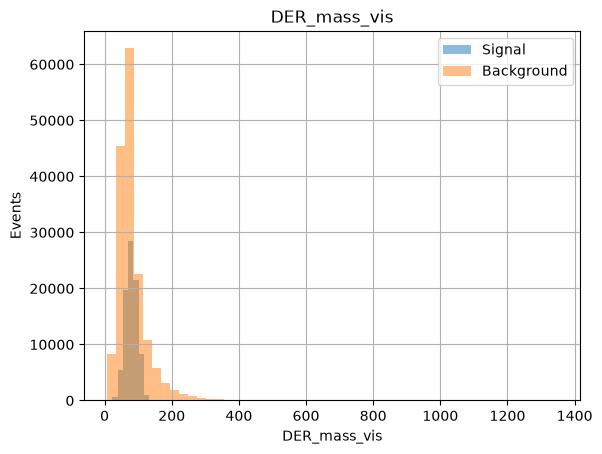

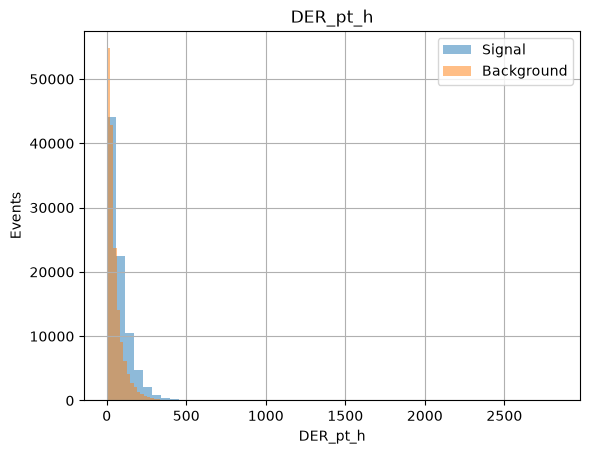

In [11]:
variables = [
    "DER_mass_MMC",
    "DER_mass_vis",
    "DER_pt_h",
]

for variable in variables:
    plt.figure()

    df[df["Label"] == "s"][variable].hist(
        bins=50,
        alpha=0.5,
        label="Signal"
    )

    df[df["Label"] == "b"][variable].hist(
        bins=50,
        alpha=0.5,
        label="Background"
    )

    plt.xlabel(variable)
    plt.ylabel("Events")
    plt.title(variable)
    plt.legend()

    plt.show()

In [12]:
missing_mmc = (df["DER_mass_MMC"] == -999)

print(f"Unavailable MMC values: {missing_mmc.sum():,}")
print(f"Fraction: {missing_mmc.mean():.1%}")

Unavailable MMC values: 38,114
Fraction: 15.2%


In [13]:
pd.crosstab(
    df["Label"],
    missing_mmc,
    normalize="index"
)

DER_mass_MMC,False,True
Label,,
b,0.785320,0.214680
s,0.966907,0.033093
